In [1]:
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/udemy_serie_arima/bin/python


ambiente de interesse udemy_serie_arima

In [2]:
# no linux

# conda env list
# # conda environments:
# #
# base                  *  /home/fabiene/anaconda3
# Maq2                     /home/fabiene/anaconda3/envs/Maq2
# RBA_est                  /home/fabiene/anaconda3/envs/RBA_est
# Robyn                    /home/fabiene/anaconda3/envs/Robyn
# Udemy                    /home/fabiene/anaconda3/envs/Udemy
# YouTube                  /home/fabiene/anaconda3/envs/YouTube
# face-env                 /home/fabiene/anaconda3/envs/face-env
# orange3                  /home/fabiene/anaconda3/envs/orange3
# pycaret-env              /home/fabiene/anaconda3/envs/pycaret-env


#(base) fabiene@~$ conda create --name udemy_serie_arima
# conda activate udemy_serie_arima
# (udemy_serie_arima) fabiene@:~$ 




instalar o jupyter web

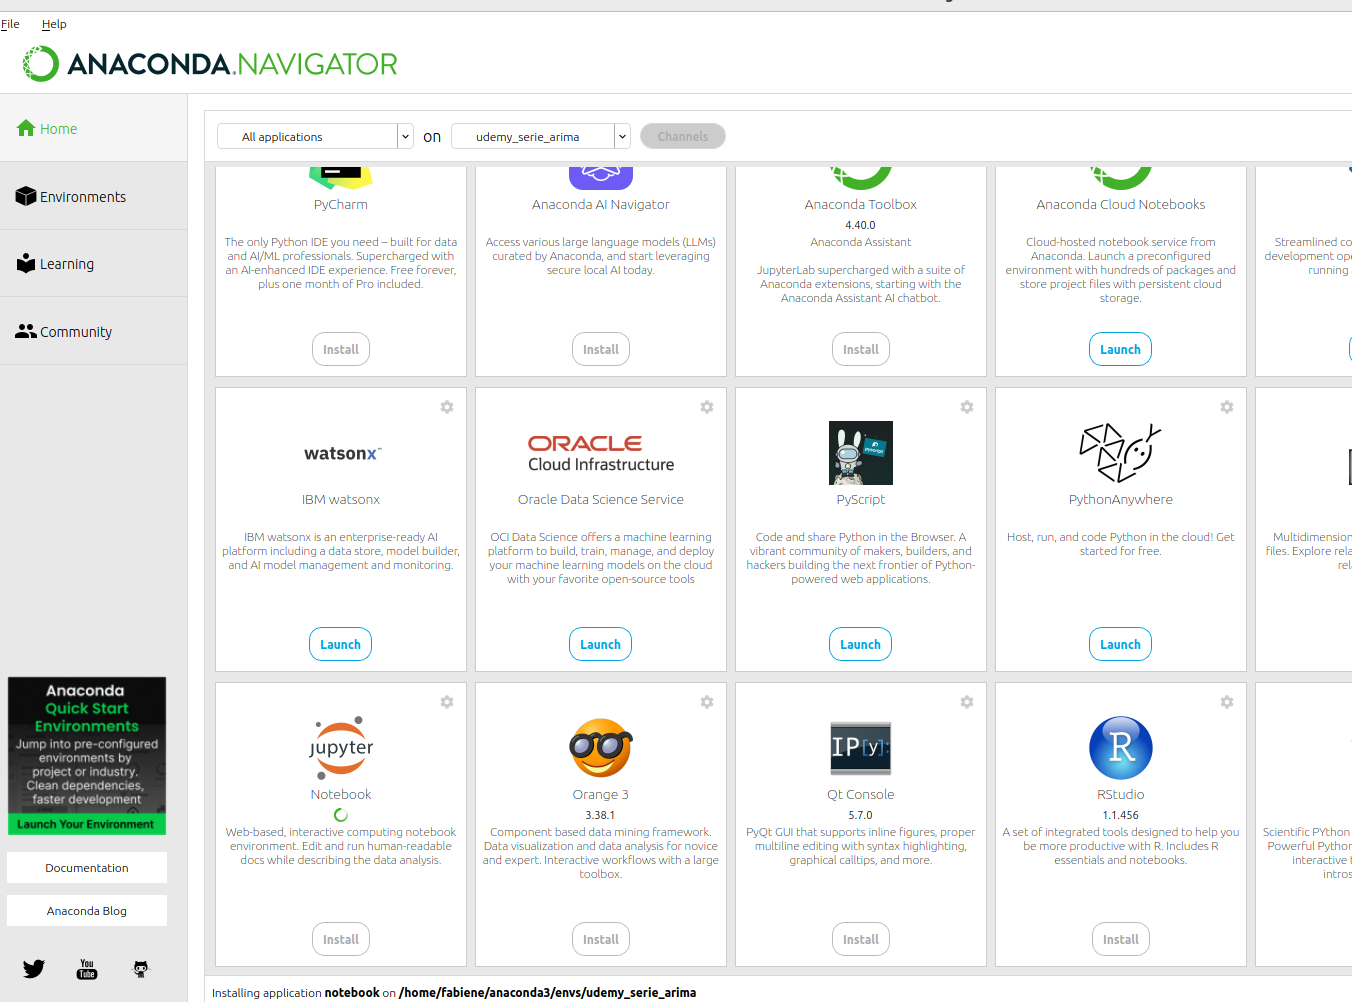

## Etapa 1: Instalação da biblioteca

In [3]:
# !pip install pmdarima
# # Atualizado em 31/05/2025
# !pip install numpy==1.26.4 # <-- incluir versão do NumPy
# exit() # utilizado para reiniciar o ambiente após as instalações

## Etapa 2: Importação das bibliotecas

In [4]:
#!pip install matplotlib

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from datetime import datetime
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.arima import auto_arima

In [6]:
# no linux, buscar o arquivo
# find -name '*passenger*'
    
# ./anaconda3/envs/pycaret-env/lib/python3.11/site-packages/pmdarima/datasets/airpassengers.py
# ./anaconda3/envs/pycaret-env/lib/python3.11/site-packages/pmdarima/datasets/__pycache__/airpassengers.cpython-311.pyc
# ./anaconda3/envs/YouTube/lib/python3.12/site-packages/pmdarima/datasets/airpassengers.py
# ./anaconda3/envs/YouTube/lib/python3.12/site-packages/pmdarima/datasets/__pycache__/airpassengers.cpython-312.pyc
# ./anaconda3/envs/Maq2/lib/python3.12/site-packages/gymnasium/envs/toy_text/img/passenger.png
# ./anaconda3/envs/Udemy/lib/python3.11/site-packages/pmdarima/datasets/airpassengers.py
# ./anaconda3/envs/Udemy/lib/python3.11/site-packages/pmdarima/datasets/__pycache__/airpassengers.cpython-311.pyc
# ./Documentos/Fabiene/Estatistica_estudos/PYTHON_Analise_LIVRONielsen/Capitulo_3/international-airline-passengers.csv



# (udemy_serie_arima) fabiene@:~$ find -name '*Passenger*'
# ./Documentos/Fabiene/UDEMY_ML/Serie_Temporal/Mod5-ModeloArima_serie_temporal/Programa_modelos_arima/AirPassengers.csv
# ./Documentos/Fabiene/UDEMY_ML/Serie_Temporal/Mod4-Fundamentos_Serie_Temporal/programacao/AirPassengers_2.csv
# ./Documentos/Fabiene/UDEMY_ML/Serie_Temporal/Mod4-Fundamentos_Serie_Temporal/programacao/AirPassengers.csv
# ./Documentos/Fabiene/UDEMY_ML/Prophet/modulo2_arquivos/AirPassengers.csv
# ./Documentos/Fabiene/UDEMY_ML/Prophet/Modulo4/AirPassengers.csv
# ./Documentos/Fabiene/Estatistica_estudos/PYTHON_Analise_LIVRONielsen/Capitulo_3/Aula_cap_3/AirPassengers.csv


## Etapa 3: Carregamento da base de dados

In [7]:
arquivo = "/home/fabiene/Documentos/Fabiene/UDEMY_ML/Serie_Temporal/Mod4-Fundamentos_Serie_Temporal/programacao/AirPassengers.csv"
dataset = pd.read_csv(arquivo)

In [8]:
dataset.tail(5)

,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [9]:
dataset.head(5)

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [10]:
print(f'Quantidade de linhas nos dados {len(dataset)}.')

Quantidade de linhas nos dados 144.


In [11]:
dateparse = lambda dates: pd.datetime.strptime(dates, '%Y-%m')


In [12]:
dateparse

<function __main__.<lambda>(dates)>

In [13]:
# transformar em série temporal
# # Solução direta e moderna
# dataset = pd.read_csv(
#     arquivo, 
#     parse_dates=['Month'], 
#     index_col='Month', 
#     date_format='%Y-%m'  # Substitui o date_parser
# )

# print(dataset.head())

In [14]:
from datetime import datetime
#import pandas as pd

# Correção da função: usamos datetime.strptime em vez de pd.datetime.strptime
dateparse = lambda dates: datetime.strptime(dates, '%Y-%m')

dataset = pd.read_csv(
    arquivo, 
    parse_dates=['Month'], 
    index_col='Month', 
    date_parser=dateparse  # Vai funcionar, mas continuará dando o aviso de "FutureWarning"
)

/tmp/ipykernel_7083/1669486510.py:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  dataset = pd.read_csv(


In [15]:
dataset.head() # mês com índice e a quantidade de passageiros a coluna

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [16]:
time_series = dataset['#Passengers']

In [17]:
time_series

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: #Passengers, Length: 144, dtype: int64

## Etapa 4: Exploração da série temporal

In [18]:
# coletar a segunda linha
time_series[1]

/tmp/ipykernel_7083/577436162.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  time_series[1]


np.int64(118)

In [19]:
time_series['1949-02']

Month
1949-02-01    118
Name: #Passengers, dtype: int64

In [20]:
# coletando pela data
time_series[datetime(1949,2,1)]

np.int64(118)

In [21]:
time_series['1950-01-01':'1950-07-31']

Month
1950-01-01    115
1950-02-01    126
1950-03-01    141
1950-04-01    135
1950-05-01    125
1950-06-01    149
1950-07-01    170
Name: #Passengers, dtype: int64

In [22]:
time_series[:'1950-07-31'] # dados até 31/07/1950

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
1949-11-01    104
1949-12-01    118
1950-01-01    115
1950-02-01    126
1950-03-01    141
1950-04-01    135
1950-05-01    125
1950-06-01    149
1950-07-01    170
Name: #Passengers, dtype: int64

In [23]:
# apenas dados de 1950
time_series['1950']

Month
1950-01-01    115
1950-02-01    126
1950-03-01    141
1950-04-01    135
1950-05-01    125
1950-06-01    149
1950-07-01    170
1950-08-01    170
1950-09-01    158
1950-10-01    133
1950-11-01    114
1950-12-01    140
Name: #Passengers, dtype: int64

In [24]:
# maior data 
time_series.index.max()

Timestamp('1960-12-01 00:00:00')

In [25]:
# menor data
time_series.index.min()

Timestamp('1949-01-01 00:00:00')

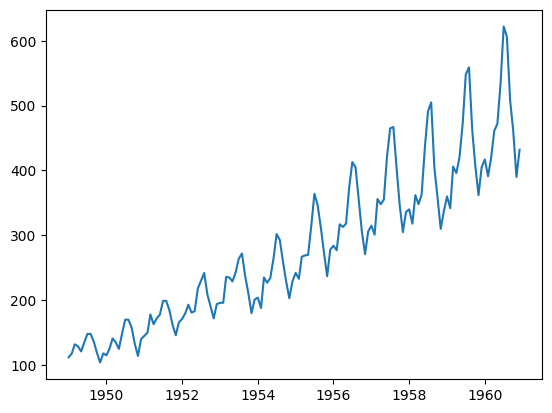

In [26]:
plt.plot(time_series)

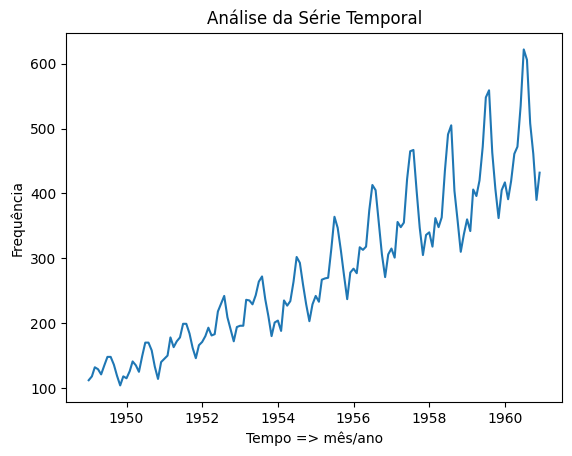

In [27]:
# gráfico
plt.plot(time_series)

# Adiciona os nomes nos eixos
plt.xlabel('Tempo => mês/ano')
plt.ylabel('Frequência')

# título 
plt.title('Análise da Série Temporal')

# Exibe 
plt.show()

série temporal com tendência de crescimento

/tmp/ipykernel_7083/2916739138.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  time_series_ano = time_series.resample('A').sum()


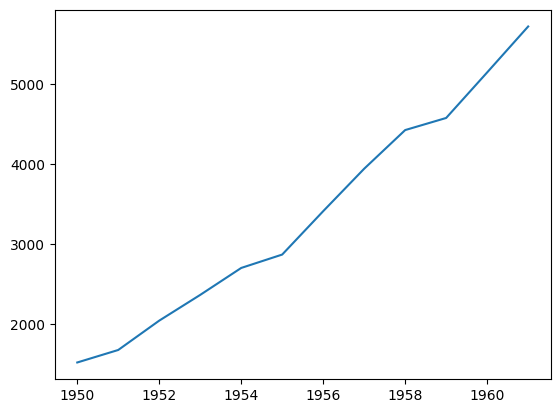

In [28]:
# agrupamento por ano
time_series_ano = time_series.resample('A').sum()
plt.plot(time_series_ano)

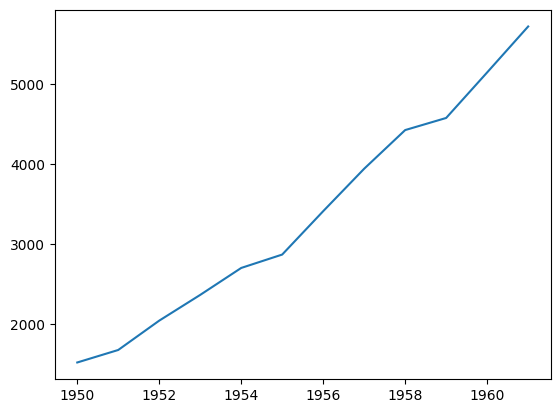

In [29]:
time_series_ano = time_series.resample('YE').sum() # somar por ano
plt.plot(time_series_ano)

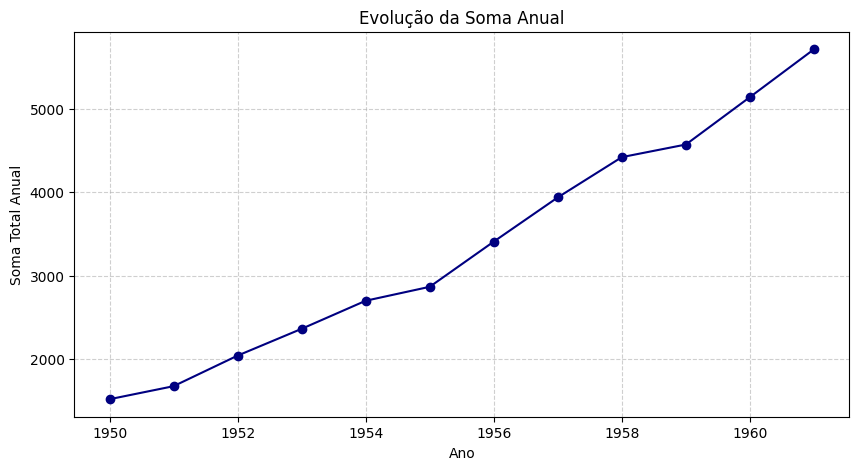

In [30]:
import matplotlib.pyplot as plt

# Criando o gráfico
plt.figure(figsize=(10, 5))
plt.plot(time_series_ano, marker='o', color='navy', linestyle='-')

# Adicionando as legendas nos eixos
plt.xlabel('Ano')
plt.ylabel('Soma Total Anual')
plt.title('Evolução da Soma Anual')

# Adicionando uma grade para facilitar a visualização dos valores
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

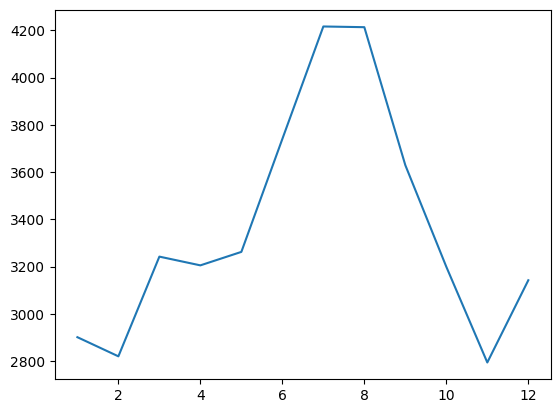

In [31]:
# somatório por mês
time_series_mes = time_series.groupby([lambda x: x.month]).sum()
plt.plot(time_series_mes)

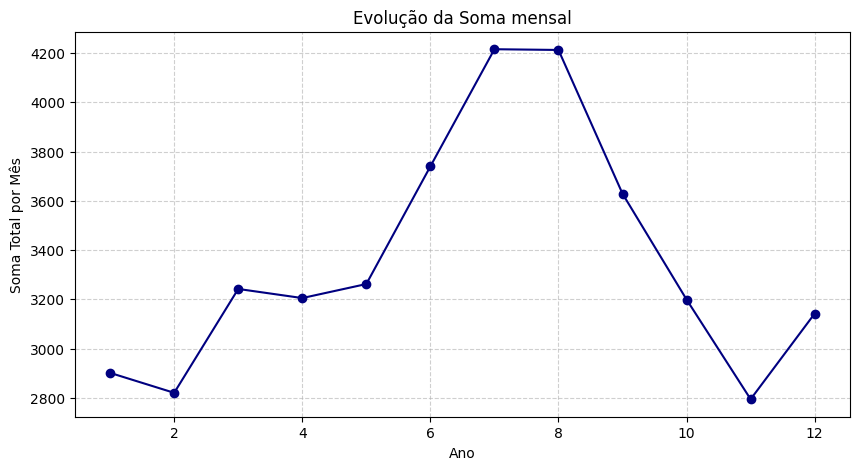

In [32]:
# Criando o gráfico
plt.figure(figsize=(10, 5))
plt.plot(time_series_mes, marker='o', color='navy', linestyle='-')

# Adicionando as legendas nos eixos
plt.xlabel('Ano')
plt.ylabel('Soma Total por Mês')
plt.title('Evolução da Soma mensal')

# Adicionando uma grade para facilitar a visualização dos valores
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

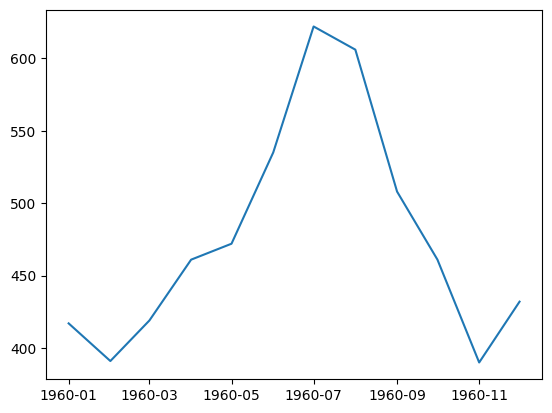

In [33]:
# filtro do ano de interesse
time_series_datas = time_series['1960-01-01':'1960-12-01']
plt.plot(time_series_datas)

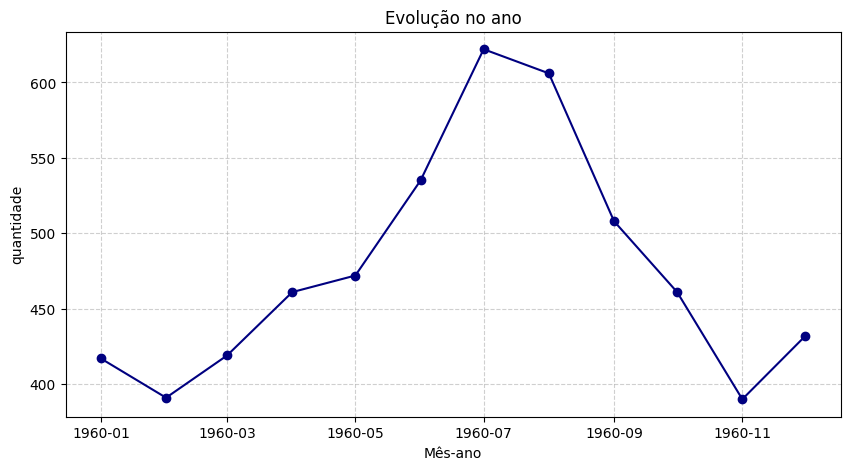

In [34]:
# Criando o gráfico
plt.figure(figsize=(10, 5))
plt.plot(time_series_datas, marker='o', color='navy', linestyle='-')

# Adicionando as legendas nos eixos
plt.xlabel('Mês-ano')
plt.ylabel('quantidade')
plt.title('Evolução no ano')

# Adicionando uma grade para facilitar a visualização dos valores
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## 30.9) Etapa 5: Decomposição da série temporal

In [35]:
decomposicao = seasonal_decompose(time_series)
tendencia = decomposicao.trend
sazonal = decomposicao.seasonal
aleatorio = decomposicao.resid # resíduo

divisão e analisar por parte a decomposição

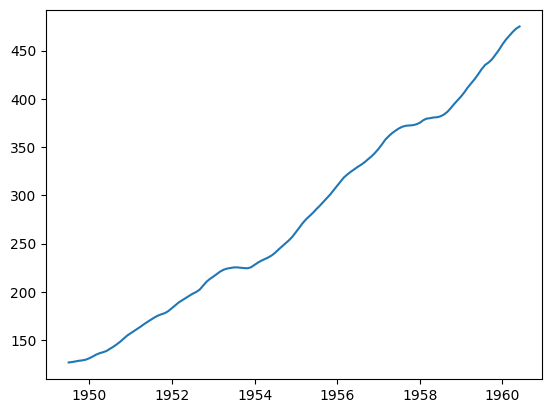

In [36]:
plt.plot(tendencia) # tendência de crescimento

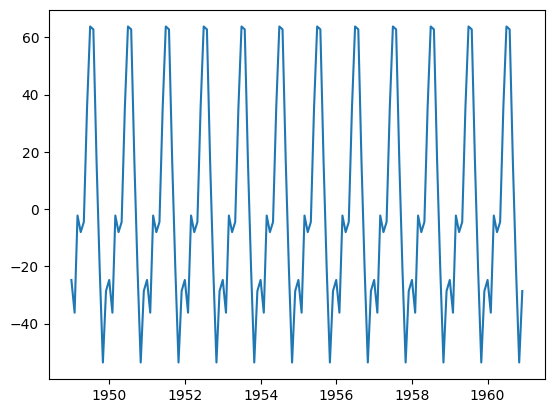

In [37]:
plt.plot(sazonal) # efeito sazonal, picos nas férias do verão do Hemisfério Norte

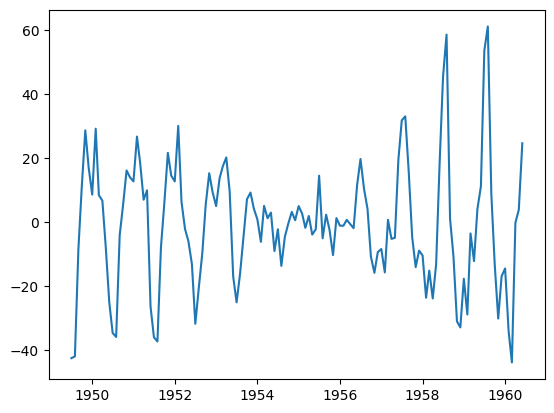

In [38]:
plt.plot(aleatorio)

Resíduo entre 1954 e 1956 não houve um crescimento significativo nos voos, tem que pesquisar.

## Etapa 6: Previsões com ARIMA

In [39]:
# parâmetros P,Q, e D

model = auto_arima(time_series, order=(2,1,2))

predictions = model.predict(n_periods=12)


In [40]:
model.order

(4, 1, 3)

In [41]:
predictions

1961-01-01    467.573918
1961-02-01    490.494792
1961-03-01    509.137175
1961-04-01    492.554950
1961-05-01    495.306038
1961-06-01    475.947797
1961-07-01    476.339809
1961-08-01    475.552121
1961-09-01    472.353869
1961-10-01    483.889752
1961-11-01    475.570304
1961-12-01    485.921649
Freq: MS, dtype: float64

In [42]:
model

,order,"(4, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,False


In [43]:
model.get_params()

{'maxiter': 50,
 'method': 'lbfgs',
 'order': (4, 1, 3),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': False}

In [44]:
# tirandos os parâmetros pré definidos

In [45]:
# Parâmetors P, Q e D
model = auto_arima(time_series)

In [46]:
model.order

(4, 1, 3)

In [47]:
model.get_params()

{'maxiter': 50,
 'method': 'lbfgs',
 'order': (4, 1, 3),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': False}

In [48]:
predictions = model.predict(n_periods=24)

In [49]:
predictions

1961-01-01    467.573918
1961-02-01    490.494792
1961-03-01    509.137175
1961-04-01    492.554950
1961-05-01    495.306038
1961-06-01    475.947797
1961-07-01    476.339809
1961-08-01    475.552121
1961-09-01    472.353869
1961-10-01    483.889752
1961-11-01    475.570304
1961-12-01    485.921649
1962-01-01    479.133719
1962-02-01    480.987520
1962-03-01    482.221463
1962-04-01    476.211099
1962-05-01    483.942882
1962-06-01    475.847434
1962-07-01    482.794346
1962-08-01    479.012042
1962-09-01    479.518731
1962-10-01    482.449531
1962-11-01    476.974036
1962-12-01    483.511102
Freq: MS, dtype: float64

In [50]:
# previsão de 2 anos para frente

## Etapa 7 - Gráfico das previsões

### Quantos registros há na time série

In [54]:
print(f'Quantidade de registros na série dos dados {len(time_series)}.')

Quantidade de registros na série dos dados 144.


In [55]:
# coletar 130 registros no treino
train = time_series[:130]
train.shape

(130,)

In [56]:
train.tail(2)

Month
1959-09-01    463
1959-10-01    407
Name: #Passengers, dtype: int64

In [57]:
train.index.min(), train.index.max()

(Timestamp('1949-01-01 00:00:00'), Timestamp('1959-10-01 00:00:00'))

In [59]:
test = time_series[130:] # resto dos dados para teste
test.shape

(14,)

In [61]:
print(f'quantidade de registros de teste {test.shape[0]}.')

quantidade de registros de teste 14.


In [62]:
test.index.min(), test.index.max()

(Timestamp('1959-11-01 00:00:00'), Timestamp('1960-12-01 00:00:00'))

In [63]:
# para os warning, ou as aviso dos processos, não aparecer suppress_warnings=True

model2 = auto_arima(train, suppress_warnings=True)

In [64]:
model2.get_params()

{'maxiter': 50,
 'method': 'lbfgs',
 'order': (2, 1, 2),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': True}

In [66]:
train.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1959-01-01', '1959-02-01', '1959-03-01', '1959-04-01',
               '1959-05-01', '1959-06-01', '1959-07-01', '1959-08-01',
               '1959-09-01', '1959-10-01'],
              dtype='datetime64[ns]', name='Month', length=130, freq=None)

In [65]:
test.index

DatetimeIndex(['1959-11-01', '1959-12-01', '1960-01-01', '1960-02-01',
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', freq=None)

faremos a previsão para 14 dias, igual à quantidade de meses do teste

In [69]:
prediction = pd.DataFrame(model2.predict(n_periods=14), index=test.index)
print(prediction)
prediction.columns = ['passengers_predictions'] # renomear a coluna
prediction

                     0
Month                 
1959-11-01  357.690515
1959-12-01  334.857456
1960-01-01  342.488599
1960-02-01  375.944537
1960-03-01  424.126293
1960-04-01  473.151451
1960-05-01  510.388388
1960-06-01  527.724252
1960-07-01  523.268340
1960-08-01  501.198781
1960-09-01  469.991485
1960-10-01  439.680424
1960-11-01  418.990066
1960-12-01  413.125667


,passengers_predictions
Month,
1959-11-01,357.690515
1959-12-01,334.857456
1960-01-01,342.488599
1960-02-01,375.944537
1960-03-01,424.126293
1960-04-01,473.151451
1960-05-01,510.388388
1960-06-01,527.724252
1960-07-01,523.268340


In [71]:
test # teste, com valores reais

Month
1959-11-01    362
1959-12-01    405
1960-01-01    417
1960-02-01    391
1960-03-01    419
1960-04-01    461
1960-05-01    472
1960-06-01    535
1960-07-01    622
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: #Passengers, dtype: int64

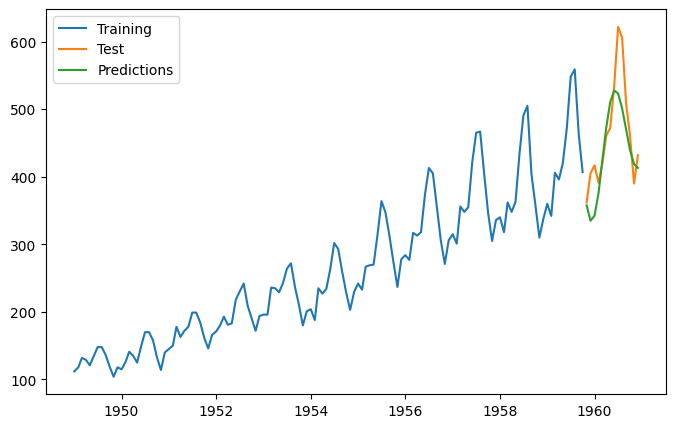

In [72]:
plt.figure(figsize=(8,5))
plt.plot(train, label = 'Training')
plt.plot(test, label = 'Test')
plt.plot(prediction, label = 'Predictions')
plt.legend();